# How To Categorize ML Problems



- Author: Denise Case, Kim Hummel
- Date: 2026-07
- Dataset: Seaborn Titanic
- Target: Survived 



## Section 1. Project Setup and Imports

All imports and configuration appear once, at the top of the notebook.
Bring in the libraries, configure a logger,
set a few constants you may customize, and
confirm the packages are installed by logging their versions.



In [9]:
# === Section 1a. DECLARE IMPORTS (BRING IN FREE CODE) ===

from importlib.metadata import version  # to verify
import logging  # for type hinting
import platform  # to verify
from typing import Final  # for type hinting

from datafun_toolkit.logger import get_logger, log_header
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# === Section 1b. CONFIGURE LOGGER ONCE PER NOTEBOOK ===

LOG: logging.Logger = get_logger("M01", level="DEBUG")
log_header(LOG, "M01")

# === Section 1c. USE THE LOGGER TO VERIFY IMPORTS ===

# If any do NOT return a version number, then that package is not installed correctly.
# Check your pyproject.toml and re-run environment setup commands.

LOG.info("Confirming installation:")
LOG.info(f"  python:       {platform.python_version()}")
LOG.info(f"  pandas:       {version('pandas')}")
LOG.info(f"  numpy:        {version('numpy')}")
LOG.info(f"  scikit-learn: {version('scikit-learn')}")
LOG.info(f"  seaborn:      {version('seaborn')}")
LOG.info(f"  matplotlib:   {version('matplotlib')}")

sns_dataset_list = sns.get_dataset_names()  # shows all built-in datasets
LOG.info(f"Built-in Seaborn datasets: {sns_dataset_list}")

# === Section 1d. SET PANDAS DISPLAY CONFIGURATION (helps in notebooks) ===

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

2026-07-05 12:13:30 | INFO | M01 | === RUN START ===
2026-07-05 12:13:30 | INFO | M01 | project=M01
2026-07-05 12:13:30 | INFO | M01 | repo_dir=ml-01-intro
2026-07-05 12:13:30 | INFO | M01 | python=3.14.3
2026-07-05 12:13:30 | INFO | M01 | os=Windows 11
2026-07-05 12:13:30 | INFO | M01 | shell=powershell
2026-07-05 12:13:30 | INFO | M01 | cwd=notebooks
2026-07-05 12:13:30 | INFO | M01 | github_actions=False
2026-07-05 12:13:30 | INFO | M01 | Confirming installation:
2026-07-05 12:13:30 | INFO | M01 |   python:       3.14.3
2026-07-05 12:13:30 | INFO | M01 |   pandas:       3.0.3
2026-07-05 12:13:30 | INFO | M01 |   numpy:        2.5.0
2026-07-05 12:13:30 | INFO | M01 |   scikit-learn: 1.9.0
2026-07-05 12:13:30 | INFO | M01 |   seaborn:      0.13.2
2026-07-05 12:13:30 | INFO | M01 |   matplotlib:   3.11.0
2026-07-05 12:13:30 | INFO | M01 | Built-in Seaborn datasets: ['anagrams', 'anscombe', 'attention', 'brain_networks', 'car_crashes', 'diamonds', 'dots', 'dowjones', 'exercise', 'flight

## Section 2. Load the Data


In [10]:
# === Section 2. Load the Data ===

# We are loading data from Seaborn's built-in datasets,
# which are small datasets included with the Seaborn library
# for practice and demonstration purposes.
# They are listed above with sns.get_dataset_names().
# Experiment with different ones to see what they contain.
# You can also load from CSV files, databases, or APIs and process is similar.

# CUSTOM: In this example, I load a Seaborn dataset by name (no external CSV).
# Change to explore a different dataset.
DATASET_NAME: Final[str] = "titanic"

LOG.info(f"Loading dataset: {DATASET_NAME}")
df: pd.DataFrame = sns.load_dataset(DATASET_NAME)
LOG.info(f"Loaded: {df.shape[0]} rows (instances), {df.shape[1]} columns")

2026-07-05 12:13:30 | INFO | M01 | Loading dataset: titanic
2026-07-05 12:13:30 | INFO | M01 | Loaded: 891 rows (instances), 15 columns


## Section 3. Inspect and Characterize the Data

Important:

- Name the parts of a dataset using ML vocabulary.
- Describe the dataset using machine-learning vocabulary.

WHY: All ML starts here.
First, name the instances, the numeric features, and the categorical columns.
Then, decide what kind of ML question the data can answer.

- Each ROW is one INSTANCE.
- Each COLUMN is a candidate FEATURE or TARGET.
- NUMERIC columns can be a regression target or a numeric feature.
- CATEGORICAL columns can be a classification target or a category feature.


2026-07-05 12:13:30 | INFO | M01 | Instances (rows): 891
2026-07-05 12:13:30 | INFO | M01 | Columns:          15
2026-07-05 12:13:30 | INFO | M01 | Numeric columns (regression target / numeric feature): ['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']
2026-07-05 12:13:30 | INFO | M01 | Categorical columns (classification target / category): ['sex', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']
2026-07-05 12:13:30 | INFO | M01 | Missing values by column:
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64
2026-07-05 12:13:30 | INFO | M01 | Missing values across all columns: 869
2026-07-05 12:13:30 | DEBUG | M01 | First rows:
2026-07-05 12:13:30 | DEBUG | M01 | 
   survived  pclass     sex   age  sibsp 

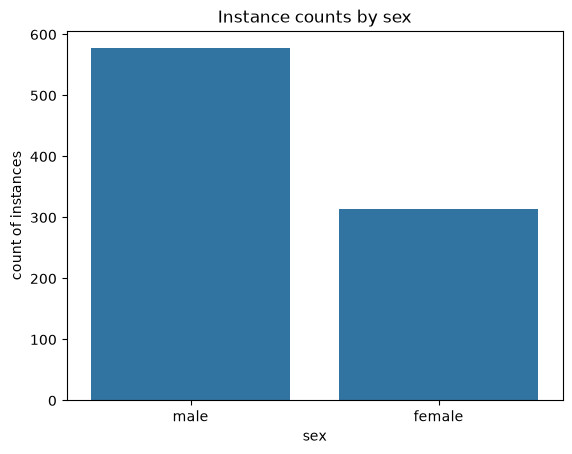

In [11]:
# === Section 3. Inspect and Characterize the Data in ML Terms ===

row_count, col_count = df.shape

LOG.info(f"Instances (rows): {row_count}")  # or df.shape[0]
LOG.info(f"Columns:          {col_count}")  # or df.shape[1] or len(df.columns)

numeric_cols_list: list[str] = df.select_dtypes(include="number").columns.tolist()
category_cols_list: list[str] = df.select_dtypes(exclude="number").columns.tolist()

LOG.info(f"Numeric columns (regression target / numeric feature): {numeric_cols_list}")
LOG.info(
    f"Categorical columns (classification target / category): {category_cols_list}"
)

missing: pd.Series = df.isna().sum()
LOG.info(f"Missing values by column:\n{missing}")

missing_total: int = int(missing.sum())
LOG.info(f"Missing values across all columns: {missing_total}")

LOG.debug("First rows:")
LOG.debug(f"\n{df.head()}")

# A first picture.
# Visualize something in every project.
# If the column is a category, a countplot is a good first look at the distribution of instances across categories.

# If the category_cols_list is not empty, then make a plot of the first categorical column.
if category_cols_list:
    # start a new figure
    plt.figure()

    # get the name of the  first categorical column (index is 0)
    plot_col_name: str = category_cols_list[0]

    # countplot shows the count of instances in each category for the specified column
    sns.countplot(data=df, x=plot_col_name)

    # Set the title and axis labels for the plot
    plt.title(f"Instance counts by {plot_col_name}")
    plt.xlabel(plot_col_name)
    plt.ylabel("count of instances")

    # Show the plot
    plt.show()

## Section 4. Frame an ML Question

A column becomes a "target" when we decide to try to predict it.

Picking the target fixes the kind of ML problem:

- if target is a NUMBER, then regression
- if target is a CATEGORY, then classification
- no target selected, then unsupervised (e.g., clustering) - we're exploring

Report the KIND of ML problem implied by the chosen target, `CANDIDATE_TARGET`.

WHY: A dataset supports many questions. 
Choosing the target is an analyst decision; 
once chosen, whether it is numeric or categorical
determines whether the task is regression or classification, 
and the remaining columns become the candidate features (inputs).

NOTE: This does NOT decide whether the question is worth asking or
even whether ML is the right tool.


In [12]:
# === Section 4. Frame an ML Question ===

# 4.1 CHOOSE A TARGET COLUMN --------------

# Look at the dataset and pick a column to predict.
# This is the "target" variable, the thing we want to predict with machine learning.
# Do not choose an ID column or a column with unique values for each row, as those cannot be predicted.
CANDIDATE_TARGET: Final[str] = "survived"

# Check to ensure our target is in the dataset
if CANDIDATE_TARGET not in df.columns:
    LOG.warning(f"CANDIDATE_TARGET '{CANDIDATE_TARGET}' is not a column.")
    LOG.warning(f"Available columns: {df.columns.tolist()}")

LOG.info(f"Chosen target (y): {CANDIDATE_TARGET}")

# The target variable is often denoted as "y" in ML,
# and the features (the columns we will use to predict the target)
# are often denoted as "X".

# 4.2 IS THE TARGET NUMERIC OR CATEGORICAL? -----------

# use pandas API to check if the target column is numeric or not
# this determines the type of ML problem.

# We calculate it just for instructional purposes.
# Most analysts can determine this and just document it in the framing.
target_is_numeric: bool = pd.api.types.is_numeric_dtype(df[CANDIDATE_TARGET])
LOG.info(f"Target is numeric? {target_is_numeric}")

# 4.3 DETERMINE THE TYPE OF ML PROBLEM -----------

# the type is either regression (if the target is numeric) or
# classification (if the target is categorical).
problem_type: str = (
    "regression (we want to predict a number)"
    if target_is_numeric
    else "classification (we want to predict a category)"
)
LOG.info(f"Implied problem type: {problem_type}")

# 4.4 LIST CANDIDATE FEATURES -----------

# Candidate features are all columns EXCEPT the target.
# In Module 1 we just focus on framing a problem.
# We do not build a model yet,
# so we don't worry about feature selection or engineering yet.
feature_list: list[str] = [c for c in df.columns if c != CANDIDATE_TARGET]  # pyright: ignore[reportUnusedVariable]
LOG.info(f"Candidate features (X): {feature_list}")

2026-07-05 12:13:31 | INFO | M01 | Chosen target (y): survived
2026-07-05 12:13:31 | INFO | M01 | Target is numeric? True
2026-07-05 12:13:31 | INFO | M01 | Implied problem type: regression (we want to predict a number)
2026-07-05 12:13:31 | INFO | M01 | Candidate features (X): ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']


## Section 5. Summary and Next Steps

First, output key information (may use Python)
Second, provide your narrative, conclusions, and next steps (in Markdown)

In [13]:
# === Python Summary ===

LOG.info("========================")
LOG.info("SUMMARY OF KEY FACTS")
LOG.info("========================")
LOG.info(f"Dataset:           {DATASET_NAME}")
LOG.info(f"Instances:         {df.shape[0]}")
LOG.info(f"Candidate target:  {CANDIDATE_TARGET}")
LOG.info(f"Problem type:      {problem_type}")
LOG.info(f"Candidate features: {feature_list}")
LOG.info("========================")

2026-07-05 12:13:31 | INFO | M01 | ========================
2026-07-05 12:13:31 | INFO | M01 | SUMMARY OF KEY FACTS
2026-07-05 12:13:31 | INFO | M01 | ========================
2026-07-05 12:13:31 | INFO | M01 | Dataset:           titanic
2026-07-05 12:13:31 | INFO | M01 | Instances:         891
2026-07-05 12:13:31 | INFO | M01 | Candidate target:  survived
2026-07-05 12:13:31 | INFO | M01 | Problem type:      regression (we want to predict a number)
2026-07-05 12:13:31 | INFO | M01 | Candidate features: ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']
2026-07-05 12:13:31 | INFO | M01 | ========================



### Custom Narrative

AFter we imported the titanic data from seaborn we ran code to figure out the problem type. 

### Custom Conclusions

This is SUPERVISED learning (because the data includes a target - 1 for survived).

The chosen target is `survived` and that is a numeric column. 

Therefore, modeling this problem will use regression.

### Next Steps

Next steps would be to decide which candidate features should be used to predict survival. 

## Task: Make the Notebook Yours (Apply / Extend / Explore)

This is an example.
Copy this notebook and make it your own. 

In your copy:

1. At the beginning, update the Author, the purpose, the target, etc. 
2. Remove any instructions you do not need. 

Try things like the following.

1. **Apply** - Change `DATASET_NAME` to another Seaborn dataset
   (e.g., `"tips"`, `"diamonds"`, `"titanic"`) or load your own CSV into
   `data/raw/`. Re-run and check the characterization against the vocabulary.
2. **Extend** - Change `CANDIDATE_TARGET` to a numeric column and 
   then a categorical one. 
   Confirm the implied problem type flips between regression
   and classification, and explain why in a Markdown cell.
3. **Explore** - Pick a dataset where you are unsure 
   whether ML is the right tool. 
   Argue both sides in `docs/index.md`.
   There is no single correct answer; 
   the reasoning is the work / value.


## Task: Finalize Your README.md

Include in README.md:

- your project description
- any instructions
- your commands
- a link to key artifacts (including your executed notebook)

When done, you may delete this instruction in your custom notebook.


## Task: Finalize your docs/index.md

In your docs/index.md, include things like:

- Your target.
- Why predicting this target could be useful and for whom.
- Whether ML is a good tool for this problem and why or why not. 
- For example, would a simple rule work better?
- Which features look informative, and which look irrelevant.
- What might 'good enough' mean for this question.

Important:

- There is no threshold that answers these questions automatically.
- Use notebook, README.md, and docs/index.md to share your judgement and your ML skills.


## Task: Final Check

- `README.md` - reflects your description, instructions, commands, and links to your executed notebook.
- `docs/index.md` - reflects your project-specific updates.
- Your GitHub **About** section has a link to your hosted documentation site.
- The executed example notebook AND your custom notebook are available in `notebooks/`.
- Keep this **working example** alongside your custom work until your work has been assessed.
- Ensure your **custom notebook** introduces and narrates **your** custom project.

## Reminder: Run All before pushing to GitHub

Before saving a notebook (and running git add-commit-push), click 'Run All' to generate all outputs and display them in the notebook.

Follow our [pro-analytics-02](https://denisecase.github.io/pro-analytics-02/) common workflows.

Your README.md should have a description, a link to your executed notebook, and a list of commands (updated as you add your custom description, instructions, and commands).

Your docs/ folder should document your custom project analysis in the `docs/index.md` summary.
